# NaiveBayes & SVM using TF-IDF Benchmark: Hate & Offensive Speech Classification

In [6]:
import os
import re
import sys
import pickle 
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
sns.set_palette("deep")

from datasets import load_dataset, concatenate_datasets
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import learning_curve

from preprocessing import tokenize_function as tokenize

os.makedirs("./results/naive_bayes", exist_ok=True)
os.makedirs("./results/svm", exist_ok=True)

In [7]:
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.8.0


## Load Dataset

In [8]:
ds = load_dataset("MartynaKopyta/hate_offensive_tweets")

train_ds = ds["train"].rename_column("text_cleaned", "text")
# val_ds   = ds["validation"].rename_column("text_cleaned", "text")
test_ds  = ds["test"].rename_column("text_cleaned", "text")

print(f"Train : {len(train_ds)}")
print(f"Test  : {len(test_ds)}")

Train : 23541
Test  : 1962


In [9]:
train_ds[0]

{'text': 'RT _Dorsey: My trash is worth more than you', 'label': 2}

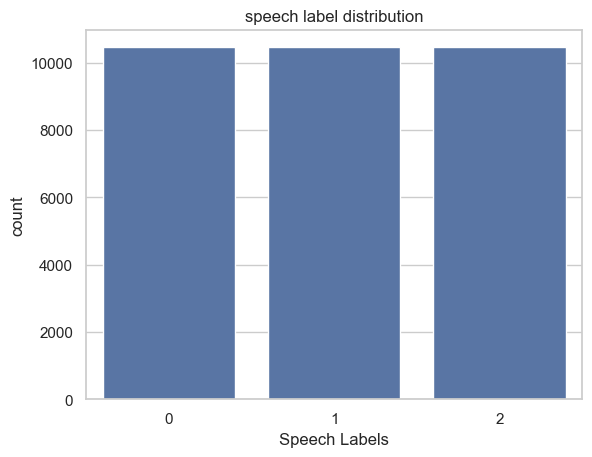

In [10]:
train = pd.DataFrame(ds["train"])
val = pd.DataFrame(ds["validation"])
test = pd.DataFrame(ds["test"])

df = pd.concat([train, val, test], ignore_index=True)

sns.countplot(data=df, x="label")
plt.title("speech label distribution")
plt.xlabel("Speech Labels")
plt.ylabel("count")
plt.show()

In [11]:
X_train = train_ds["text"]
y_train = train_ds["label"]
X_test  = test_ds["text"]
y_test  = test_ds["label"]

total_labels = len(set(train_ds["label"]))
id2label = {
    0: "hate", 
    1: "offensive", 
    2: "neither",
}
label2id = {v: k for k, v in id2label.items()}

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print(f"Num classes: {total_labels}")

Train size : 23541
Test size  : 1962
Num classes: 3


## Minimal Preprocessing + TF-IDF

In [12]:
def clean_text(text):
    text = str(text)
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

def tokenize_function(text):
    text = clean_text(text)
    text = text.lower()
    return re.findall(r"[a-z0-9]+(?:'[a-z]+)?", text)

In [13]:
tfidf = TfidfVectorizer(
    tokenizer=tokenize,
    preprocessor=None,
    lowercase=False,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=50_000
)

In [14]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test) : {X_test_tfidf.shape}")

TF-IDF matrix shape (train): (23541, 50000)
TF-IDF matrix shape (test) : (1962, 50000)


In [15]:
def show_learning_curve(model, name, X, y, cv, ax=None):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # training curve
    ax.plot(
        train_sizes,
        train_mean,
        'o-',
        color='blue',
        label=f'Training: {train_mean[-1]:.4f}'
    )
    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
        color='blue'
    )

    # validation curve
    ax.plot(
        train_sizes,
        test_mean,
        'o-',
        color='green',
        label=f'Validation: {test_mean[-1]:.4f}'
    )
    ax.fill_between(
        train_sizes,
        test_mean - test_std,
        test_mean + test_std,
        alpha=0.2,
        color='green'
    )

    ax.set_title(f'Learning Curve ({name})')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('Balanced Accuracy')
    ax.grid(True)
    ax.legend()

## Training

### 1. Naive Bayes

In [16]:
nb_model = ComplementNB(alpha=0.1)   # alpha: laplace smoothing
nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


### 2. Support Vector Machine (SVM)

In [17]:
svm_base = LinearSVC(C=1.0, max_iter=2000)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(max_iter=2000)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, 

## Evaluation

In [18]:
def evaluate(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="macro")

    return acc, f1, recall, precision

def plot_confusion_matrix(y_true, y_pred):
    labels = list(id2label.values())  # ["hate", "offensive", "neither"]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

def show_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    return df_report

In [19]:
def get_size_mb(vectorizer, model):
    obj = {
        "vectorizer": vectorizer,
        "model": model
    }
    obj_bytes = pickle.dumps(obj)
    return sys.getsizeof(obj_bytes) / 1024**2

In [20]:
def measure_latency(vectorizer, model, text, warmup=10, runs=100):
    # warmup
    for _ in range(warmup):
        x = vectorizer.transform([text])
        _ = model.predict(x)

    start = time.perf_counter()

    for _ in range(runs):
        x = vectorizer.transform([text])
        _ = model.predict(x)

    end = time.perf_counter()

    latency_ms = ((end - start) / runs) * 1000
    return latency_ms

### 1. Naive Bayes

#### 1. Performance Metrics

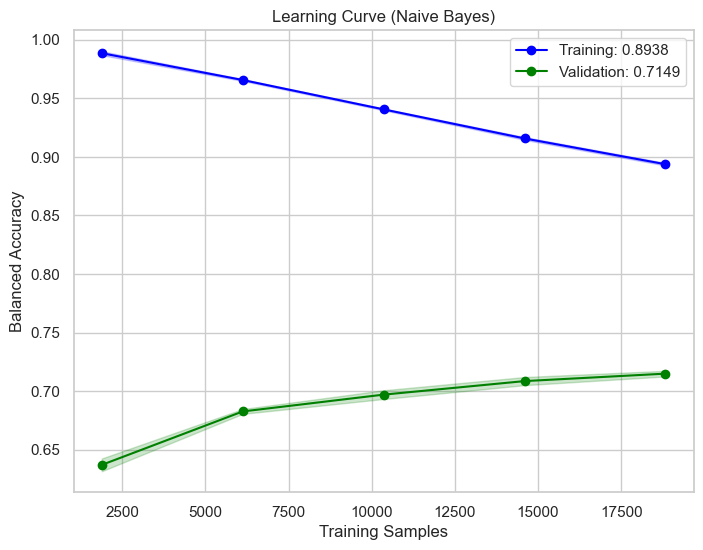

In [21]:
show_learning_curve(nb_model, "Naive Bayes", X_train_tfidf, y_train, cv=5)

In [22]:
nb_preds = nb_model.predict(X_test_tfidf)
nb_acc, nb_f1, nb_recall, nb_precision = evaluate(y_test, nb_preds)

print("Accuracy:", nb_acc)
print("F1 Score:", nb_f1)
print("Recall:", nb_recall)
print("Precision:", nb_precision)

Accuracy: 0.7232415902140673
F1 Score: 0.7180398987684837
Recall: 0.7247390303812241
Precision: 0.7323083425107694


In [23]:
y_test_labels = [id2label[label] for label in y_test]
nb_preds_labels = [id2label[label] for label in nb_preds]

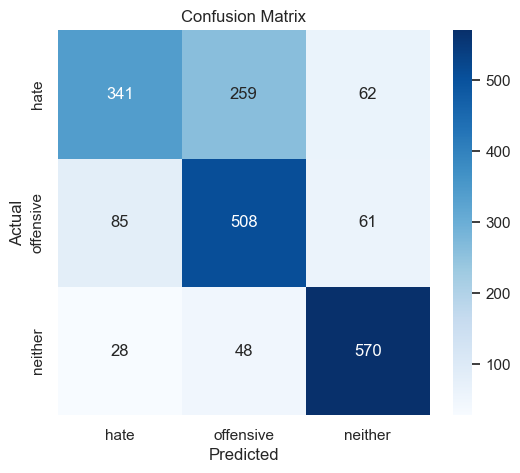

In [24]:
plot_confusion_matrix(y_test_labels, nb_preds_labels)

In [25]:
show_report(y_test_labels,nb_preds_labels)

,precision,recall,f1-score,support
hate,0.751101,0.515106,0.611111,662.000000
neither,0.822511,0.882353,0.851382,646.000000
offensive,0.623313,0.776758,0.691627,654.000000
accuracy,0.723242,0.723242,0.723242,0.723242
macro avg,0.732308,0.724739,0.718040,1962.000000
weighted avg,0.732017,0.723242,0.717060,1962.000000


#### 2. Compute Metrics

In [26]:
nb_size = get_size_mb(vectorizer=tfidf, model=nb_model)
print(f"NB model size: {nb_size:.4f} MB")

NB model size: 4.5278 MB


In [27]:
example_text = "haha i know this is a test sample, but you are so stupid"

latency = measure_latency(
    vectorizer=tfidf,
    model=nb_model,
    text=example_text,
    warmup=10,
    runs=100
)

print(f"Inference latency: {latency:.4f} ms/sample")

Inference latency: 0.4308 ms/sample


In [28]:
with open("./results/naive_bayes/model.pkl", "wb") as f:
    pickle.dump(nb_model, f)

with open("./results/naive_bayes/tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

### 2. Support Vector Machine (SVM)

#### 1. Performance Metrics

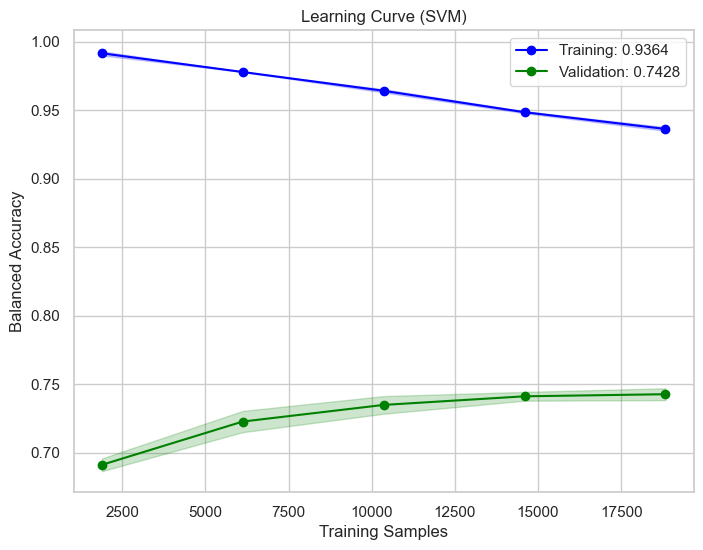

In [29]:
show_learning_curve(svm_model, "SVM", X_train_tfidf, y_train, cv=5)

In [30]:
svm_preds = svm_model.predict(X_test_tfidf)
svm_acc, svm_f1, svm_recall, svm_precision = evaluate(y_test, svm_preds)

print("Accuracy:", svm_acc)
print("F1 Score:", svm_f1)
print("Recall:", svm_recall)
print("Precision:", svm_precision)

Accuracy: 0.7528032619775739
F1 Score: 0.7509654734175011
Recall: 0.7542007227899049
Precision: 0.7515544081959247


In [31]:
y_test_labels = [id2label[label] for label in y_test]
svm_preds_labels = [id2label[label] for label in svm_preds]

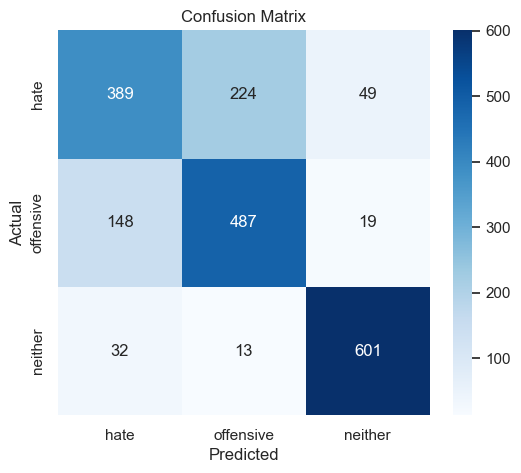

In [32]:
plot_confusion_matrix(y_test_labels, svm_preds_labels)

In [33]:
show_report(y_test_labels, svm_preds_labels)

,precision,recall,f1-score,support
hate,0.683656,0.587613,0.632006,662.000000
neither,0.898356,0.930341,0.914068,646.000000
offensive,0.672652,0.744648,0.706821,654.000000
accuracy,0.752803,0.752803,0.752803,0.752803
macro avg,0.751554,0.754201,0.750965,1962.000000
weighted avg,0.750679,0.752803,0.749815,1962.000000


#### 2. Compute Metrics

In [34]:
svm_size = get_size_mb(vectorizer=tfidf, model=svm_model)
print(f"SVM model size: {svm_size:.4f} MB")

SVM model size: 5.2923 MB


In [35]:
example_text = "haha i know this is a test sample, but you are so stupid"

latency = measure_latency(
    vectorizer=tfidf,
    model=svm_model,
    text=example_text,
    warmup=10,
    runs=100
)

print(f"Inference latency: {latency:.4f} ms/sample")

Inference latency: 0.6964 ms/sample


In [36]:
with open("./results/svm/model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

with open("./results/svm/tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

## Inference Example

In [37]:
with open("./results/naive_bayes/model.pkl", "rb") as f:
    nb_model = pickle.load(f)

with open("./results/svm/model.pkl", "rb") as f:
    svm_model = pickle.load(f)

with open("./results/naive_bayes/tfidf.pkl", "rb") as f:
    tfidf = pickle.load(f)  # same vectorizer for both

In [38]:
def predict(text, model, label_map):
    vec   = tfidf.transform([text])
    pred  = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
    return {
        "label": label_map[pred], 
        "score": round(float(proba[pred]), 4),
    }

In [39]:
print("input text:", example_text)

print("\nNaive Bayes:", predict(example_text, nb_model, id2label))
print("SVM        :", predict(example_text, svm_model, id2label))

input text: haha i know this is a test sample, but you are so stupid

Naive Bayes: {'label': 'hate', 'score': 0.4679}
SVM        : {'label': 'hate', 'score': 0.7303}
